<a href="https://colab.research.google.com/github/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIOPAL Project**
# **Title of project: Among adults aged 20-80, using data collected from the 2007-2008 to 2015-2016 NHANES cycles, Does depression predict higher fasting glucose, HbA1c, oral glucose tolerance test and fasting insulin biomarkers?**

## Group members and contributions:

| Member | Student Name | Student Number | Contribution to the project |
|--------|--------------|------------------|--------------------------------------------------------
|1| Sreya |  S10240940C  | (3) Logistic Regression analysis|
|2| Benetta | S10268028F | (2) Data exploration |
| 3| Tian  Yu | S10240966C | (1) Data preparation and (4) predictive analysis using XGBoost |

### Link to GitHub repository:
### Link to Google Colab:



# **1. Data loading and preparation**

### **1.1 Importing of libraries, loading of functions and preliminary cleaning**


In [1]:
import pandas as pd
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
# -----------------------------
# Generic data loader (EDITED)
# -----------------------------

TINY_THRESHOLD = 1e-6

def load_data(file_prefix, columns, years, cycles, dtype_map=None):
    urls = [
        f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        for y, c in zip(years, cycles)
    ]

    df_list = []
    for url in urls:
        try:
            df = pd.read_sas(url)

            use_cols = [col for col in columns if col in df.columns]
            df = df[use_cols].copy()

            # Force numeric where possible
            for col in use_cols:
                df[col] = pd.to_numeric(df[col], errors="coerce")

            # Clean tiny floating-point artifacts
            for col in df.columns:
                if pd.api.types.is_float_dtype(df[col]):
                    df[col] = df[col].apply(
                        lambda x: 0 if pd.notna(x) and abs(x) < TINY_THRESHOLD else x
                    )

            # Cast dtypes if provided
            if dtype_map is not None:
                df = df.astype(dtype_map)

            df_list.append(df)

        except Exception as e:
            print(f"Could not load {url}: {e}")

    if not df_list:
        return pd.DataFrame(columns=columns)

    return pd.concat(df_list, ignore_index=True)

In [3]:
# -----------------------------
# NHANES cycles (OGTT available)
# -----------------------------
years  = ["2007", "2009", "2011", "2013", "2015"]
cycles = ["E", "F", "G", "H", "I"]

# -----------------------------
# Load datasets (with casting)
# -----------------------------
df_demo = load_data(
    "DEMO",
    ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "INDFMPIR"],
    years, cycles,
    dtype_map={
        "SEQN": "int64",
        "RIDAGEYR": "Int64",
        "RIAGENDR": "Int64",
        "RIDRETH1": "Int64",
        "INDFMPIR": "float64"
    }
)

df_phq = load_data(
    "DPQ",
    ["SEQN"] + [f"DPQ0{i}0" for i in range(1, 10)],
    years, cycles,
    dtype_map={"SEQN": "int64"}
)

df_diq = load_data(
    "DIQ",
    ["SEQN", "DIQ160", "DIQ170"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DIQ160": "Int64", "DIQ170": "Int64"}
)

df_smq = load_data(
    "SMQ",
    ["SEQN", "SMQ020"],
    years, cycles,
    dtype_map={"SEQN": "int64", "SMQ020": "Int64"}
)

df_bmx = load_data(
    "BMX",
    ["SEQN", "BMXWAIST", "BMXBMI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "BMXWAIST": "float64", "BMXBMI": "float64"}
)

df_diet = load_data(
    "DR1TOT",
    ["SEQN", "DR1TKCAL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DR1TKCAL": "float64"}
)

df_paq = load_data(
    "PAQ",
    ["SEQN", "PAD680"],
    years, cycles,
    dtype_map={"SEQN": "int64", "PAD680": "float64"}
)

df_ldl = load_data(
    "TRIGLY",
    ["SEQN", "LBDLDL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDLDL": "float64"}
)

df_glu = load_data(
    "GLU",
    ["SEQN", "LBDGLUSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLUSI": "float64"}
)

df_hba1c = load_data(
    "GHB",
    ["SEQN", "LBXGH"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBXGH": "float64"}
)

df_ogtt = load_data(
    "OGTT",
    ["SEQN", "LBDGLTSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLTSI": "float64"}
)

df_ins = load_data(
    "INS",
    ["SEQN", "LBDINSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

# Insulin for cycles E, F, G from GLU file
df_ins_efg = load_data(
    "GLU",
    ["SEQN", "LBDINSI"],
    years=["2007", "2009", "2011"],
    cycles=["E", "F", "G"],
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

df_ins = pd.concat([df_ins, df_ins_efg], ignore_index=True)

# -----------------------------
# Merge everything
# -----------------------------
dfs = [
    df_demo, df_phq, df_diq, df_smq, df_bmx,
    df_diet, df_paq, df_ldl,
    df_glu, df_hba1c, df_ogtt, df_ins
]

df = reduce(lambda left, right: pd.merge(left, right, on="SEQN", how="left"), dfs)

# -----------------------------
# Final extracted dataset
# -----------------------------
print(df.shape)
df.head()


Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/INS_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/INS_G.xpt: HTTP Error 404: Not Found
(50588, 26)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,...,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI
0,41475,62,2,5,1.83,1.0,0.0,1.0,1.0,1.0,...,2,156.3,58.04,1598.0,720.0,NaN,NaN,5.7,NaN,NaN
1,41476,6,2,5,5.00,NaN,NaN,NaN,NaN,NaN,...,<NA>,52.7,15.18,2093.0,NaN,NaN,NaN,NaN,NaN,NaN
2,41477,71,1,3,1.50,0.0,0.0,0.0,0.0,0.0,...,1,109.5,30.05,914.0,240.0,NaN,NaN,9.5,NaN,NaN
3,41478,1,2,3,0.66,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,1148.0,NaN,NaN,NaN,NaN,NaN,NaN
4,41479,52,1,1,2.20,0.0,0.0,0.0,0.0,0.0,...,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.6


- The error messages above "Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found" etc. can be ignored as they are later extracted using another piece of code

 'Missingness' of each variable in the uncleaned df

In [4]:
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,9.027833
DPQ010,47.534989
DPQ020,47.544872
DPQ030,47.548826
DPQ040,47.556733
DPQ050,47.556733


### **1.2 Data cleaning**

#### 1.2.1 Removal of data for those that responded "Don't know" or "Refused to respond"

- To find the value used to code for don't know or refused, the max value of each variable is found


In [5]:
df.max()

,0
SEQN,93702.0
RIDAGEYR,80.0
RIAGENDR,2.0
RIDRETH1,5.0
INDFMPIR,5.0
DPQ010,9.0
DPQ020,9.0
DPQ030,9.0
DPQ040,9.0
DPQ050,9.0


Using the max values from the previous step,
- DPQ010 - DPQ090 -> coded as 7/9
- DIQ160, DIQ170 -> coded as 7/9
- SMQ020 -> coded as 7/9
- PAD680 -> coded as 7777/9999

These responses are cleaned out below:


In [6]:
# -----------------------------
# DPQ (PHQ-9 items)
# -----------------------------
dpq_cols = [f"DPQ0{i}0" for i in range(1, 10)]
dpq_map = {7: np.nan, 9: np.nan}

for col in dpq_cols:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# DIQ160-170, SMQ020
# -----------------------------
for col in ["DIQ160", "DIQ170", "SMQ020"]:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# PAD680 (sedentary minutes)
# -----------------------------
pad_map = {7777: np.nan, 9999: np.nan}

if "PAD680" in df.columns:
    df["PAD680"] = df["PAD680"].replace(pad_map)

# -----------------------------
# Sanity check: new max values
# -----------------------------
check_cols = dpq_cols + ["PAD680"]

for col in check_cols:
    if col in df.columns:
        print(f"Max value in {col}: {df[col].max()}")


Max value in DPQ010: 3.0
Max value in DPQ020: 3.0
Max value in DPQ030: 3.0
Max value in DPQ040: 3.0
Max value in DPQ050: 3.0
Max value in DPQ060: 3.0
Max value in DPQ070: 3.0
Max value in DPQ080: 3.0
Max value in DPQ090: 3.0
Max value in PAD680: 1380.0


PHQ-9 total scores are computed, DPQ010-DPQ090 columns are removed here.

In [7]:
# -----------------------------
# Compute PHQ-9 total score
# -----------------------------

# Keep only rows with complete PHQ-9 data
df = df.dropna(subset=dpq_cols)

# Sum PHQ-9 items
df["PHQ9_total"] = df[dpq_cols].sum(axis=1)

# Cast to int (PHQ-9 is discrete 0–27)
df["PHQ9_total"] = df["PHQ9_total"].astype(int)

# -----------------------------
# Remove DPQ item columns
# -----------------------------
df = df.drop(columns=dpq_cols)

# -----------------------------
# Check
# -----------------------------
df[["PHQ9_total"]].describe()


,PHQ9_total
count,26392.000000
mean,3.276978
std,4.348256
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,27.000000


#### 1.2.2 Filtering of non-participants from the dataset

Particpants younger than 20 or older than 79 are filtered out here.
- 80 is used to code for participants 80 years old and older in certain cycles, hence 80 is excluded and 79 is incuded

In [8]:
## Filter out participants less than 20 years old or more than 80 years old
df = df[(df["RIDAGEYR"] >= 20) & (df["RIDAGEYR"] <= 79)]
df.shape

(23529, 18)

In [9]:
## Missingness after filtering
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,8.202644
DIQ160,14.956012
DIQ170,12.835225
SMQ020,0.059501
BMXWAIST,2.779549
BMXBMI,0.837265


#### 1.2.3 Preparation of initial modelling dataframe

Any rows with missing data are removed and put into a new dataframe, ``` df_model ```, which will be used for logistic regression models



In [10]:
# Clean out all NaN rows
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')
df_model

Initial shape: (23529, 18), shape after cleaning: (6929, 18)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
4,41479,52,1,1,2.20,2,2,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.60,0
10,41485,30,2,2,1.01,2,2,2,89.7,25.99,1308.0,120.0,119.0,5.384,5.5,4.052,51.24,3
11,41486,61,2,1,1.75,2,2,2,97.0,31.21,1547.0,480.0,110.0,6.828,6.1,12.656,127.02,2
12,41487,27,1,5,5.00,2,2,2,82.9,23.44,1790.0,600.0,105.0,5.995,5.0,7.771,71.52,0
14,41489,40,2,1,2.15,2,2,2,109.2,36.59,2091.0,480.0,106.0,5.495,5.4,6.828,101.58,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,93643,64,2,4,0.20,2,2,1,111.3,41.10,956.0,60.0,166.0,6.450,6.5,10.200,81.90,0
50540,93655,38,1,3,1.15,2,2,1,92.0,24.00,2004.0,240.0,191.0,5.940,5.7,5.830,33.72,0
50548,93663,43,1,1,1.07,2,2,2,94.6,24.10,3892.0,180.0,125.0,5.440,5.0,8.050,51.90,0
50549,93664,39,1,1,4.93,1,2,2,92.5,26.00,2305.0,120.0,114.0,6.160,5.4,6.050,45.06,5


Descriptive statistics for ```df_model```

In [11]:
df_model.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
count,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000
mean,66842.801414,45.980372,1.500794,2.97229,2.584231,1.940395,1.874585,1.556935,97.798355,28.609717,2163.735460,350.033915,116.750469,5.591902,5.477832,6.478185,73.989196,2.950931
std,15175.322531,16.254717,0.500035,1.147135,1.652119,0.23677,0.331213,0.496784,15.841507,6.561219,986.391053,201.927639,34.635606,0.896687,0.545755,2.646072,61.146078,4.037557
min,41479.000000,20.0,1.0,1.0,0.000000,1.0,1.0,1.0,61.100000,15.020000,89.000000,0.000000,15.000000,3.164000,3.600000,1.277000,0.840000,0.000000
25%,53732.000000,32.0,1.0,2.0,1.110000,2.0,2.0,1.0,86.600000,24.000000,1500.000000,180.000000,93.000000,5.107000,5.200000,4.829000,36.720000,0.000000
50%,65988.000000,45.0,2.0,3.0,2.210000,2.0,2.0,2.0,96.200000,27.600000,1998.000000,300.000000,114.000000,5.495000,5.400000,5.940000,57.300000,2.000000
75%,80312.000000,60.0,2.0,4.0,4.260000,2.0,2.0,2.0,107.000000,31.800000,2636.000000,480.000000,138.000000,5.884000,5.700000,7.383000,91.140000,4.000000
max,93695.000000,79.0,2.0,5.0,5.000000,2.0,2.0,2.0,172.500000,70.100000,13687.000000,1200.000000,375.000000,22.100000,13.700000,30.100000,999.600000,27.000000


Check that there are no missing data left (delete before submission)

In [12]:
df_model.isnull().sum()/len(df)*100

,0
SEQN,0.0
RIDAGEYR,0.0
RIAGENDR,0.0
RIDRETH1,0.0
INDFMPIR,0.0
DIQ160,0.0
DIQ170,0.0
SMQ020,0.0
BMXWAIST,0.0
BMXBMI,0.0


### **1.3 Data preparation and classification**

#### 1.3.1 Initial classification of dataset

HbA1c is classified using the criteria below:

- 6.5% or higher = diabetic
- 5.7% to 6.% = prediabetic
- below 5.7% = normal

In [13]:
df["HbA1c_cat"] = pd.cut(
    df["LBXGH"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting glucose is classified using the criteria below:

- 7mmol/L or higher = diabetic
- 5.6 to 6.9mmol/L = prediabetic
- less than 5.6mmol/L = normal

In [14]:
df["FPG_cat"] = pd.cut(
    df["LBDGLUSI"],
    bins=[-np.inf, 5.6, 7.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

OGTT glucose is classified using the criteria below:

- 11.0mmol/L or higher = diabetic
- 7.8 to 11.0mmol/L = prediabetic
- less than 7.8mmol/L = normal

In [15]:
df["OGTT_cat"] = pd.cut(
    df["LBDGLTSI"],
    bins=[-np.inf, 7.8, 11.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting insulin is classified using the criteria below:

- above 78.8pmol/L = abnormally high
- 15.1-78.8 pmol/L = normal
- below 15.1pmol/L = abnormally low

In [16]:
df["Insulin_cat"] = pd.cut(
    df["LBDINSI"],
    bins=[-np.inf, 15.1, 78.8, np.inf],
    labels=["abnormally_low", "normal", "abnormally_high"],
    right=False
)

PHQ-9 data is classified using the criteria below:

- 0-4 = no/minimal depression
- 5-9 = mild
- 10-14 = moderate
- 15-19 = moderately severe
- 20-27 = severe

In [17]:
df["PHQ9_cat"] = pd.cut(
    df["PHQ9_total"],
    bins=[-np.inf, 5, 10, 15, 20, np.inf],
    labels=[
        "no_minimal",
        "mild",
        "moderate",
        "moderately_severe",
        "severe"
    ],
    right=False
)

BMI is classified using the criteria below:

- below 18.5kg/m^2 = underweight
- 18.5 - 22.9kg/m^2 = normal
- 23.0 - 27.4kg/m^2 = overweight
- more than or equal to 27.5kg/m^2 = obese

In [18]:
df["BMI_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[-np.inf, 18.5, 23.0, 27.5, np.inf],
    labels=["underweight", "normal", "overweight", "obese"],
    right=False
)

the poverty income ratio is classified using the criteria below:

- below 1.0 = below poverty line
- 1.0 to 1.99 = borderline poverty
- above 2.0 = not in poverty

In [19]:
df["PIR_cat"] = pd.cut(
    df["INDFMPIR"],
    bins=[-np.inf, 1.0, 2.0, np.inf],
    labels=["below_poverty", "borderline_poverty", "not_poor"],
    right=False
)

Waist circumference is classified using the criteria below:

- above 94cm for men = unhealthy
- above 80cm for women = unhealthy

In [20]:
df["Waist_cat"] = np.where(
    ((df["RIAGENDR"] == 1) & (df["BMXWAIST"] > 94)) |
    ((df["RIAGENDR"] == 2) & (df["BMXWAIST"] > 80)),
    "unhealthy",
    "healthy"
)

Sedentary time (converted to hours/day) is classified into the following categories, Less than 4 hrs, 4–8 hrs, 8–12 hrs, 12+ hrs:

In [21]:
df["Sedentary_cat"] = pd.cut(
    df["PAD680"] / 60,
    bins=[-np.inf, 4, 8, 12, np.inf],
    labels=["<4hrs", "4-8hrs", "8-12hrs", "12+hrs"],
    right=False
)

Participants are binned into 10 year age groups (e.g 30-40):

In [22]:
df["Age_cat"] = pd.cut(
    df["RIDAGEYR"],
    bins=range(20, 90, 10),
    right=False
)

LDL cholesterol is classified using the criteria below:

- Normal: below 100mg/dL
- Elevated: 100-129mg/dL
- Borderline high: 130-159mg/dL
- High: 160-189mg/dL
- Very high: 190mg/dL or higher

In [23]:
df["LDL_cat"] = pd.cut(
    df["LBDLDL"],
    bins=[-np.inf, 100, 130, 160, 190, np.inf],
    labels=["normal", "elevated", "borderline_high", "high", "very_high"],
    right=False
)

Calorie intake is classified using the criteria below:

- Malnutrition = < 1800kcal
- Normal = 1800-2500kcal
- Obesity = > 2500kcal

In [24]:
df["Calorie_cat"] = pd.cut(
    df["DR1TKCAL"],
    bins=[-np.inf, 1800, 2500, np.inf],
    labels=["Low", "Moderate", "High"]
)


The values for categorical variables (specifcally ```DIQ160```, ```DIQ170``` and ```SMQ020```) are mapped onto the codes used in NHANES

In [25]:
# -----------------------------
# Gender
# -----------------------------
df["RIAGENDR"] = df["RIAGENDR"].map({1: "Male", 2: "Female"})

# -----------------------------
# Ethnicity / Race
# -----------------------------
df["RIDRETH1"] = df["RIDRETH1"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
})

# -----------------------------
# Family history of diabetes / prediabetes
# -----------------------------
df["DIQ170"] = df["DIQ170"].map({1: "Yes", 2: "No"})
df["DIQ160"] = df["DIQ160"].map({1: "Yes", 2: "No"})

# -----------------------------
# Smoking status
# -----------------------------
df["SMQ020"] = df["SMQ020"].map({1: "Yes", 2: "No"})



In [26]:
## Clean out NaN rows after classification
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')

Initial shape: (23529, 30), shape after cleaning: (6929, 30)


#### 1.3.2 Visualisation of the distribution of categories for converted categorical variables

In [27]:
# --------------------------------
# List of categorical variables
# --------------------------------
cat_vars = [
    "HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "Calorie_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

# --------------------------------
# Plotting function (chunked)
# --------------------------------
def plot_categorical_distributions(df, variables, chunk_size=4):
    n_chunks = math.ceil(len(variables) / chunk_size)

    for i in range(n_chunks):
        chunk = variables[i * chunk_size:(i + 1) * chunk_size]
        fig, axes = plt.subplots(1, len(chunk), figsize=(5 * len(chunk), 4))

        if len(chunk) == 1:
            axes = [axes]

        for ax, col in zip(axes, chunk):
            counts = df[col].value_counts(dropna=False).sort_index()
            counts.plot(kind="bar", ax=ax)
            ax.set_title(col)
            ax.set_ylabel("Count")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


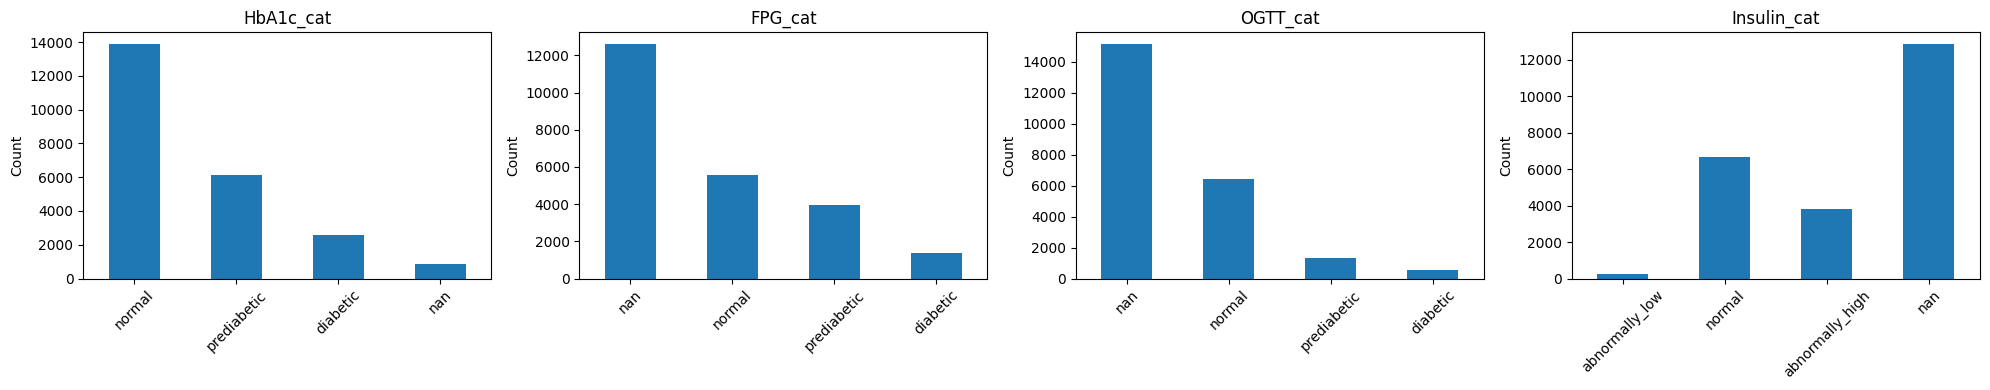

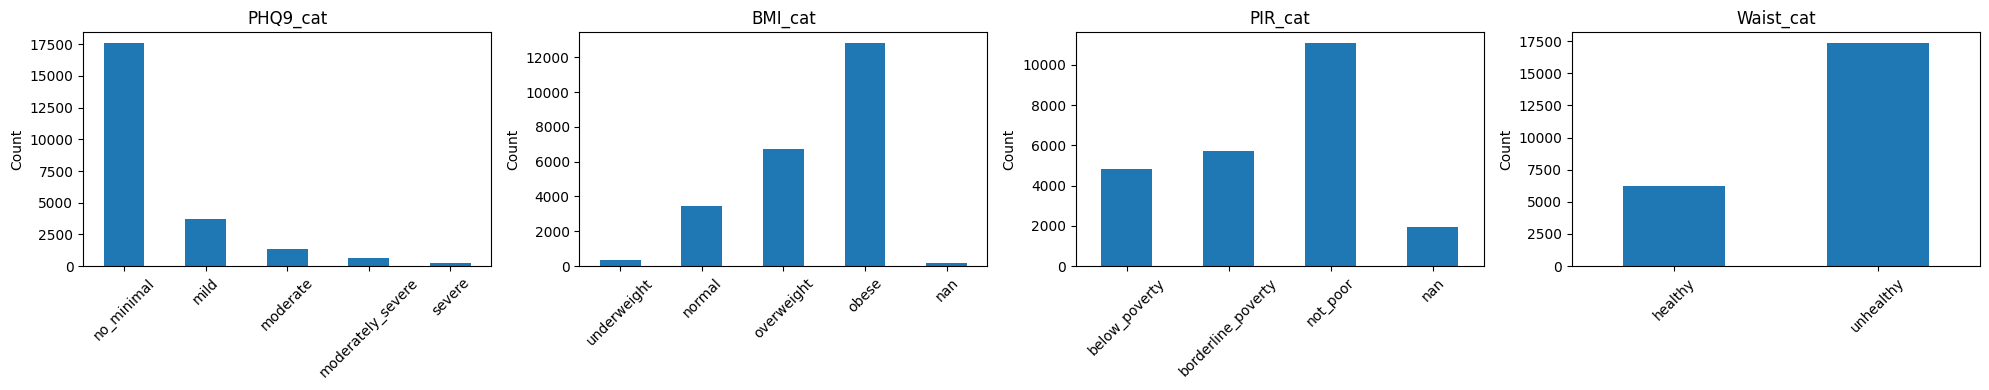

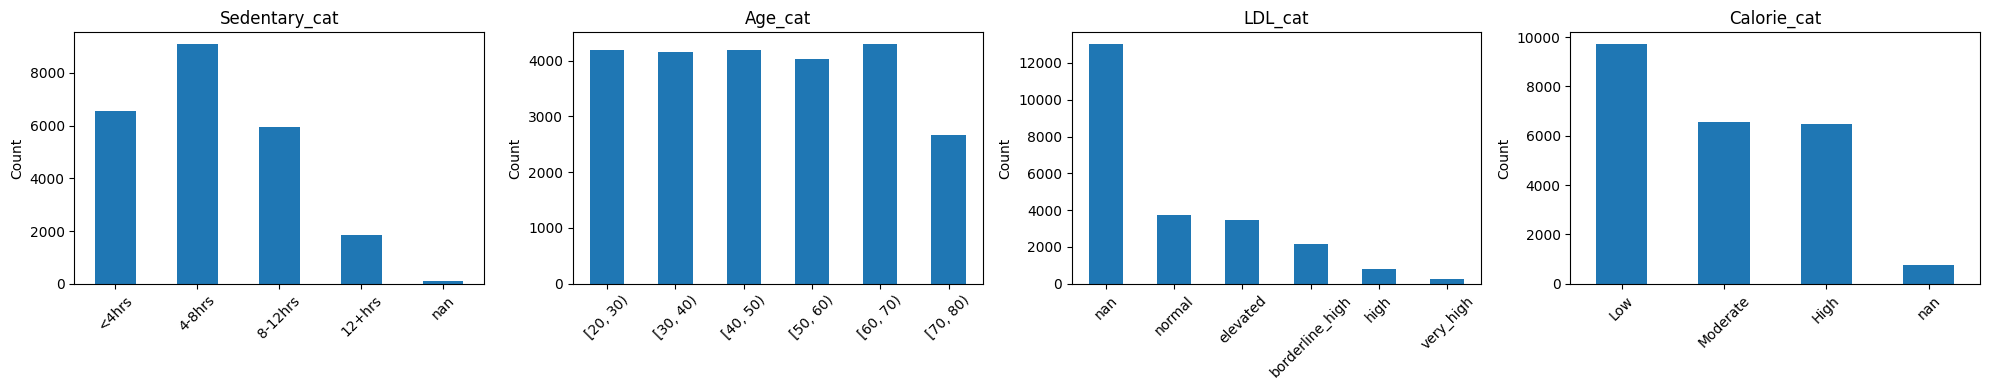

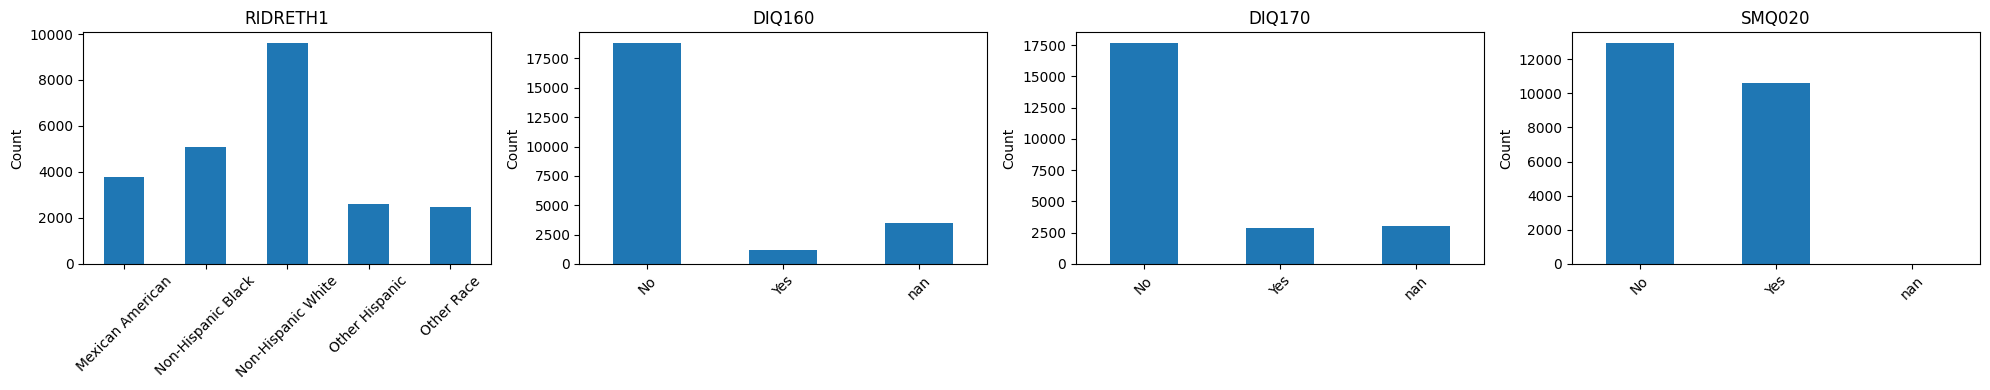

In [28]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


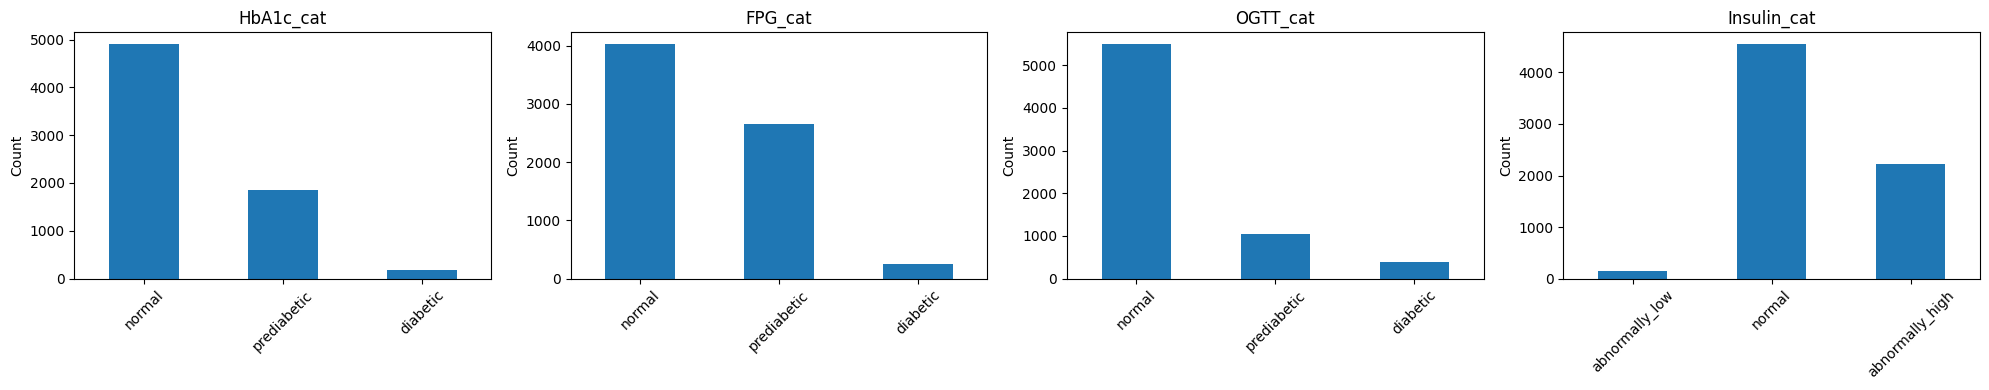

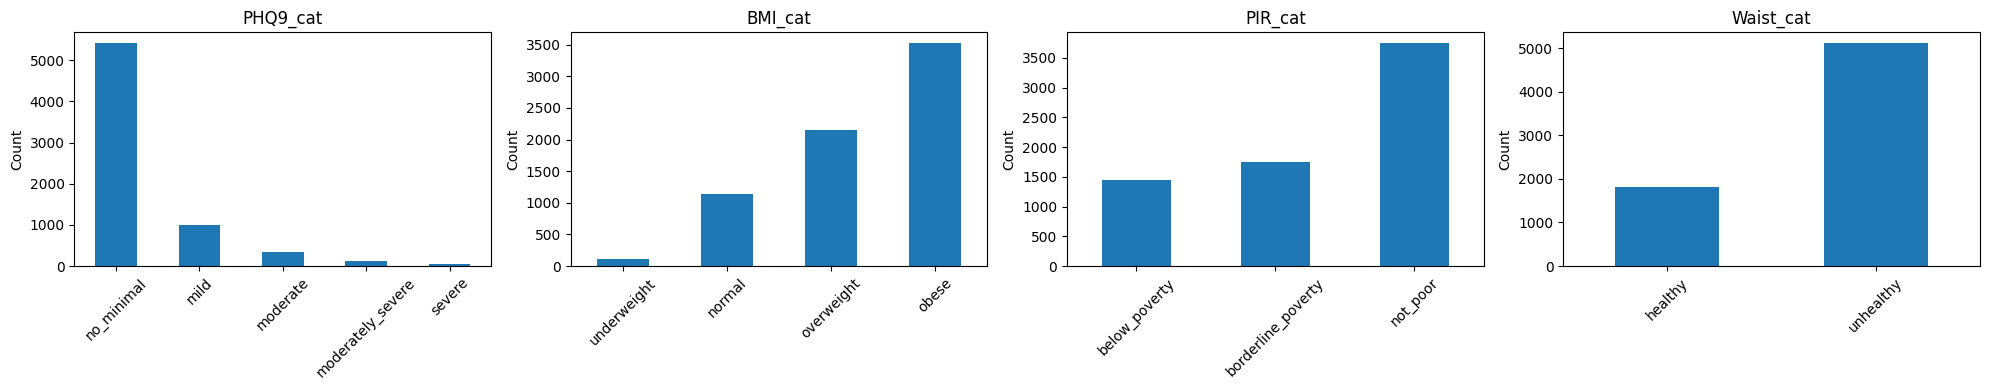

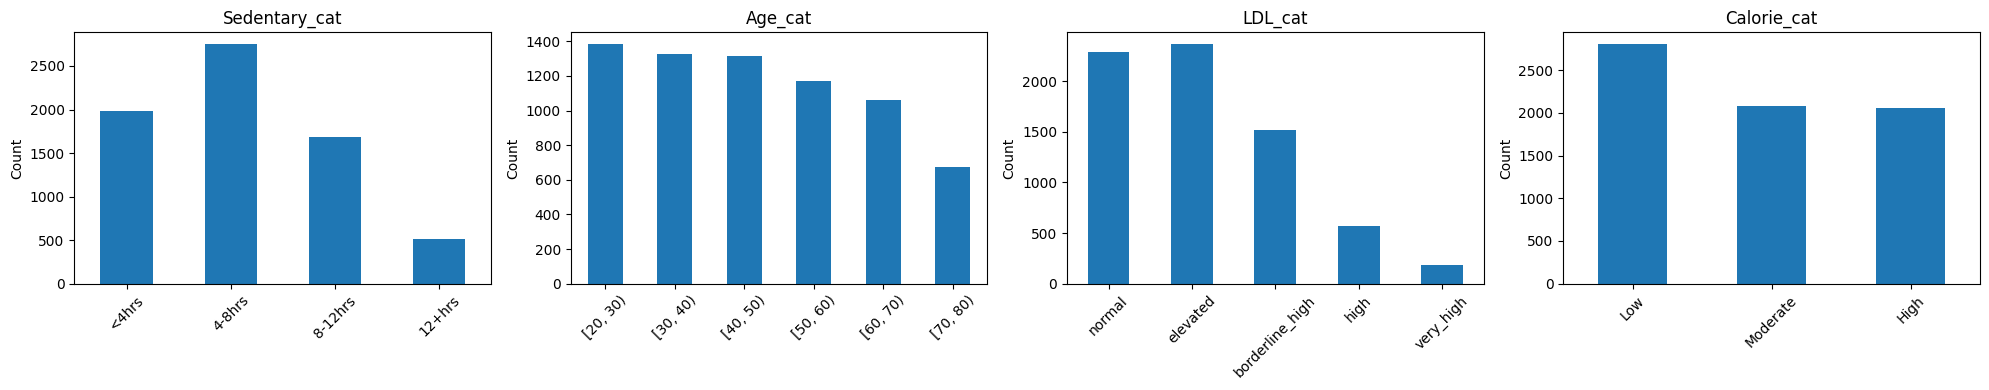

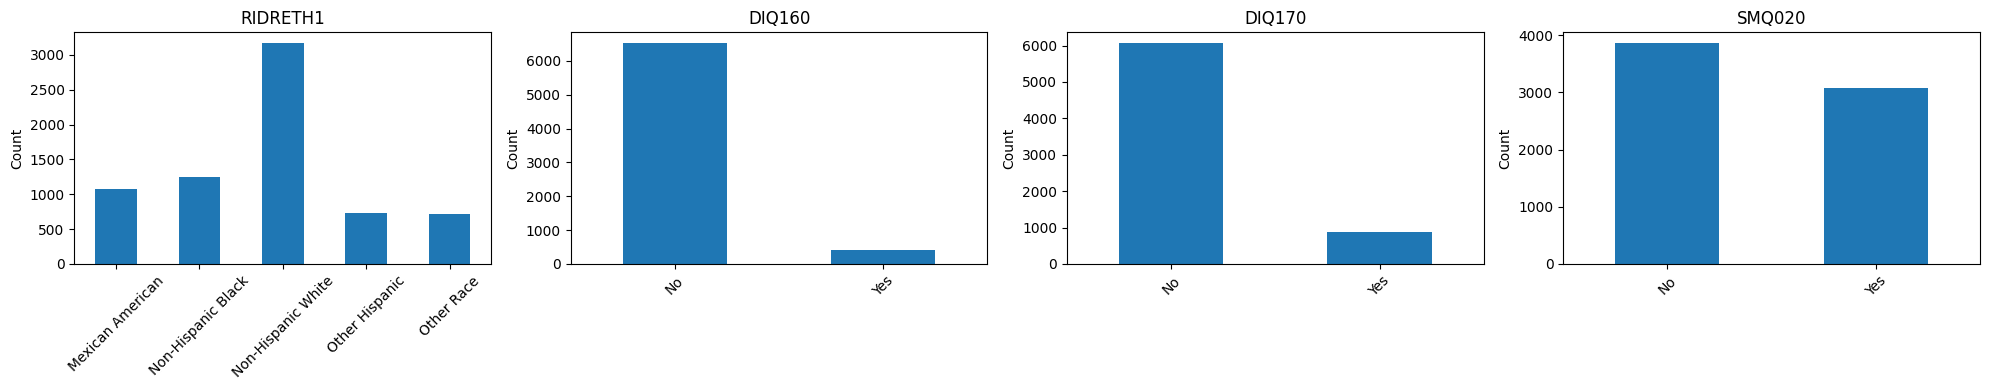

In [29]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)

#### 1.3.3 Reclassification of dataset

Based on the visualisations above, the following variables contain categories that are too sparse and will be rebinned as below:

- HbA1c, fasting glucose, OGTT glucose -> 'prediabetics' reclassified as 'diabetic'
- PHQ-9 -> 'mild', 'moderate', 'moderately severe', 'severe' reclassified as 'depressed'
- BMI -> 'underweight' reclassified as 'normal'
- Poverty-Income Ratio -> 'below poverty line' and 'borderline poverty' reclassified together as 'in poverty'
- sedentary time -> '8-12hrs' and '12+hrs' reclassfied together as '8+hrs'
- age -> [60,70) and [70,80) reclassified together as [60,80)
- LDL cholesterol -> 'borderline_high', 'high', and 'very_high' reclassified together as 'high'

In [30]:
## reclassification of biomarkers

# HbA1c: normal vs diabetic (prediabetic merged)
df["HbA1c_cat"] = np.where(
    df["HbA1c_cat"] == "normal",
    "normal",
    "diabetic"
)

# Fasting glucose
df["FPG_cat"] = np.where(
    df["FPG_cat"] == "normal",
    "normal",
    "diabetic"
)

# OGTT glucose
df["OGTT_cat"] = np.where(
    df["OGTT_cat"] == "normal",
    "normal",
    "diabetic"
)


In [31]:
## reclassification of PHQ-9
df["PHQ9_cat"] = np.where(
    df["PHQ9_cat"] == "no_minimal",
    "not_depressed",
    "depressed"
)


In [32]:
## reclassification of BMI
df["BMI_cat"] = df["BMI_cat"].replace({
    "underweight": "normal"
})


/tmp/ipython-input-1832919551.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["BMI_cat"] = df["BMI_cat"].replace({


In [33]:
## reclassification of poverty status
df["PIR_cat"] = df["PIR_cat"].replace({
    "below_poverty": "in_poverty",
    "borderline_poverty": "in_poverty"
})


/tmp/ipython-input-2741219870.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["PIR_cat"] = df["PIR_cat"].replace({


In [34]:
## reclassification of sedentary time
df["Sedentary_cat"] = df["Sedentary_cat"].replace({
    "8-12hrs": "8h+",
    "12+hrs": "8h+"
})


/tmp/ipython-input-2439367619.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Sedentary_cat"] = df["Sedentary_cat"].replace({


In [35]:
## reclassification of age groups
df["Age_cat"] = df["Age_cat"].cat.rename_categories({
    pd.Interval(70, 80, closed="left"): pd.Interval(60, 80, closed="left")
})

df["Age_cat"] = pd.Categorical(
    df["Age_cat"].apply(
        lambda x: pd.Interval(60, 80, closed="left") if x == pd.Interval(60, 70, closed="left") else x
    ),
    categories=[
        c for c in df["Age_cat"].cat.categories
        if c != pd.Interval(60, 70, closed="left")
    ],
    ordered=True
)


In [36]:
## reclassification of LDL cholesterol
df["LDL_cat"] = df["LDL_cat"].replace({
    "borderline_high": "high",
    "very_high": "high"
})


/tmp/ipython-input-3827286033.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["LDL_cat"] = df["LDL_cat"].replace({


In [37]:
## Clean out NaN rows after reclassification
df_model = df.dropna()
print(f'Shape after reclassification: {df_model.shape}')

Shape after reclassification: (6929, 30)


Summary of classifications for all relevant variables:
| Variable                                | Final Categories        | Cut-offs / Definition                             |
| --------------------------------------- | ----------------------- | ------------------------------------------------- |
| **HbA1c (%)**                           | Normal                  | < 5.7%                                            |
|                                         | Diabetic                | ≥ 5.7% (prediabetes merged into diabetic)         |
| **Fasting Glucose (mmol/L)**            | Normal                  | < 5.6                                             |
|                                         | Diabetic                | ≥ 5.6 (prediabetes merged into diabetic)          |
| **OGTT Glucose (mmol/L)**               | Normal                  | < 7.8                                             |
|                                         | Diabetic                | ≥ 7.8 (prediabetes merged into diabetic)          |
| **Fasting Insulin (pmol/L)**             | Abnormally low          | < 15.1                                            |
|                                         | Normal                  | 15.1 – 78.8                                       |
|                                         | Abnormally high         | > 78.8                                            |
| **PHQ-9 Score**                         | No / Minimal depression | 0 – 4                                             |
|                                         | Depressed               | ≥ 5 (all higher categories merged)                |
| **BMI (kg/m²)**                         | Normal                  | < 23.0 (underweight merged with normal)           |
|                                         | Overweight              | 23.0 – 27.4                                       |
|                                         | Obese                   | ≥ 27.5                                            |
| **Poverty Income Ratio (PIR)**          | In poverty              | < 2.0 (below + borderline merged)                 |
|                                         | Not in poverty          | ≥ 2.0                                             |
| **Waist Circumference (cm)**            | Healthy                 | ≤ 94 (men), ≤ 80 (women)                          |
|                                         | Unhealthy               | > 94 (men), > 80 (women)                          |
| **Sedentary Time (hours/day)**          | < 4 h                   | < 4                                               |
|                                         | 4–8 h                   | 4 to < 8                                          |
|                                         | ≥ 8 h                   | ≥ 8 (8–12 h and 12+ h merged)                     |
| **Age (years)**                         | 20–29                   | 20 to < 30                                        |
|                                         | 30–39                   | 30 to < 40                                        |
|                                         | 40–49                   | 40 to < 50                                        |
|                                         | 50–59                   | 50 to < 60                                        |
|                                         | 60–79                   | 60 to ≤ 79 (merged [60–70) + [70–80))                 |
| **LDL Cholesterol (mg/dL)**             | Normal                  | < 100                                             |
|                                         | Elevated                | 100 – 129                                         |
|                                         | High                    | ≥ 130 (borderline high + high + very high merged) |
| **Calorie Intake (kcal/day)**           | Low                     | < 1800                                            |
|                                         | Moderate                | 1800 – 2500                                       |
|                                         | High                    | > 2500                                            |
| **Smoking Status (```SMQ020```)**             | Yes                     | Ever smoked ≥ 100 cigarettes                      |
|                                         | No                      | Never smoked                                      |
| **Prediabetes diagnosis (```DIQ160```)**      | Yes / No                | Self-reported                                     |
| **Family history of diabetes (```DIQ170```)** | Yes / No                | Self-reported                                     |
| **Sex (```RIAGENDR```)**                      | Male / Female           | NHANES coded                                      |
| **Ethnicity (```RIDRETH1```)**                | 5 categories            | NHANES standard                                   |



Replotting of bar charts to evaluate rebinned data

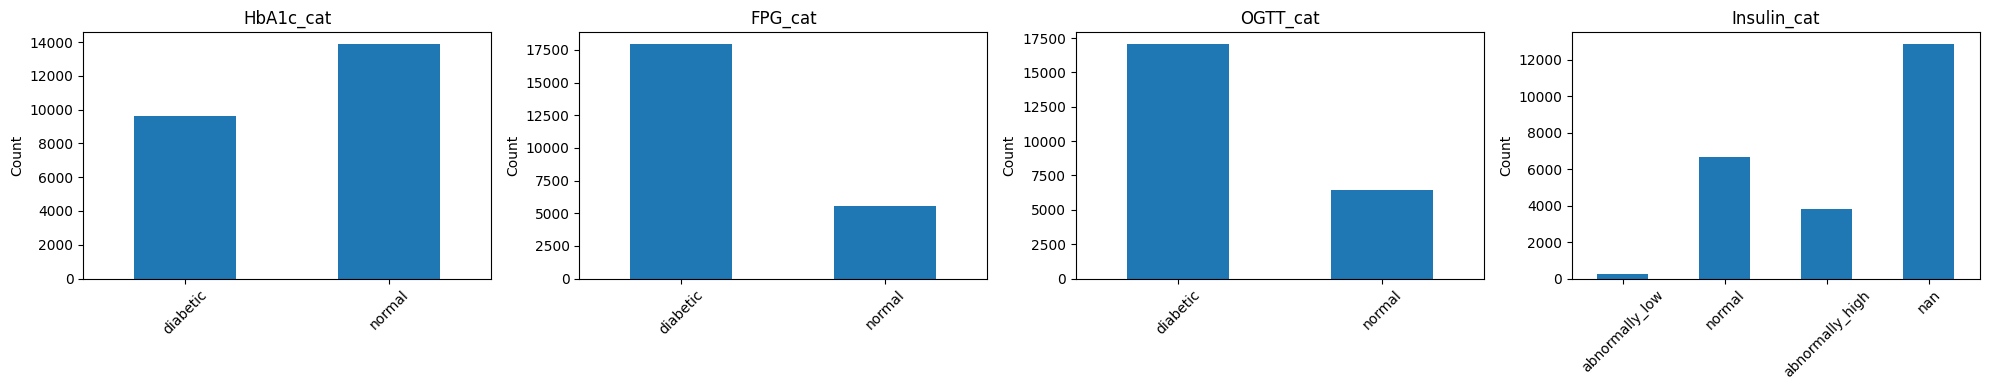

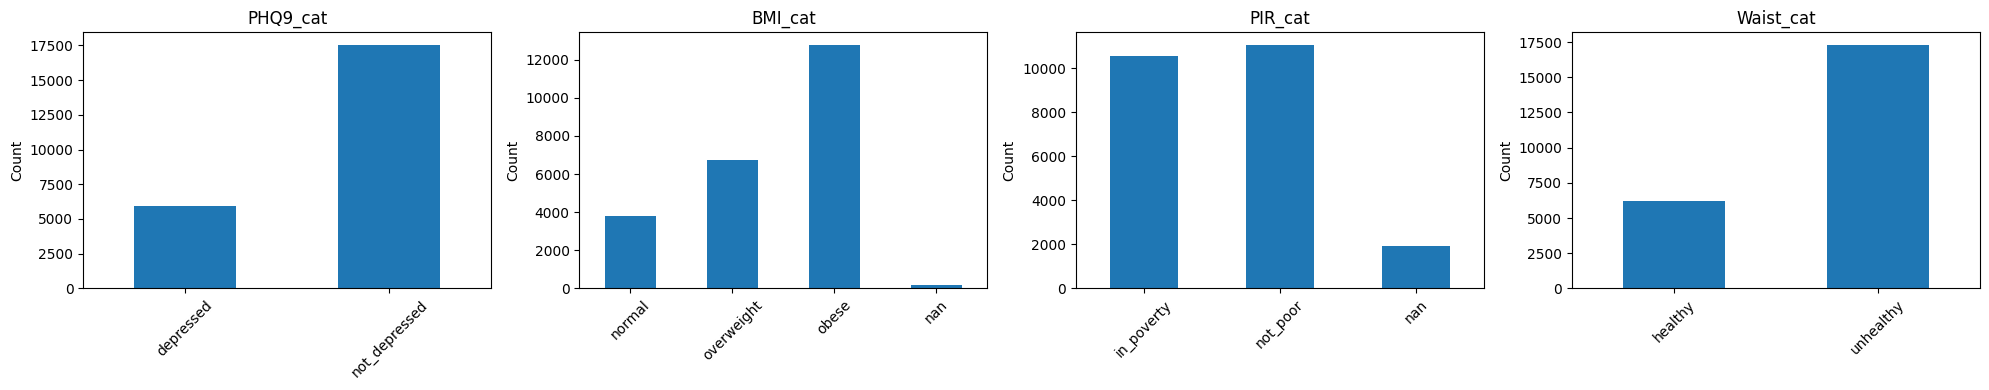

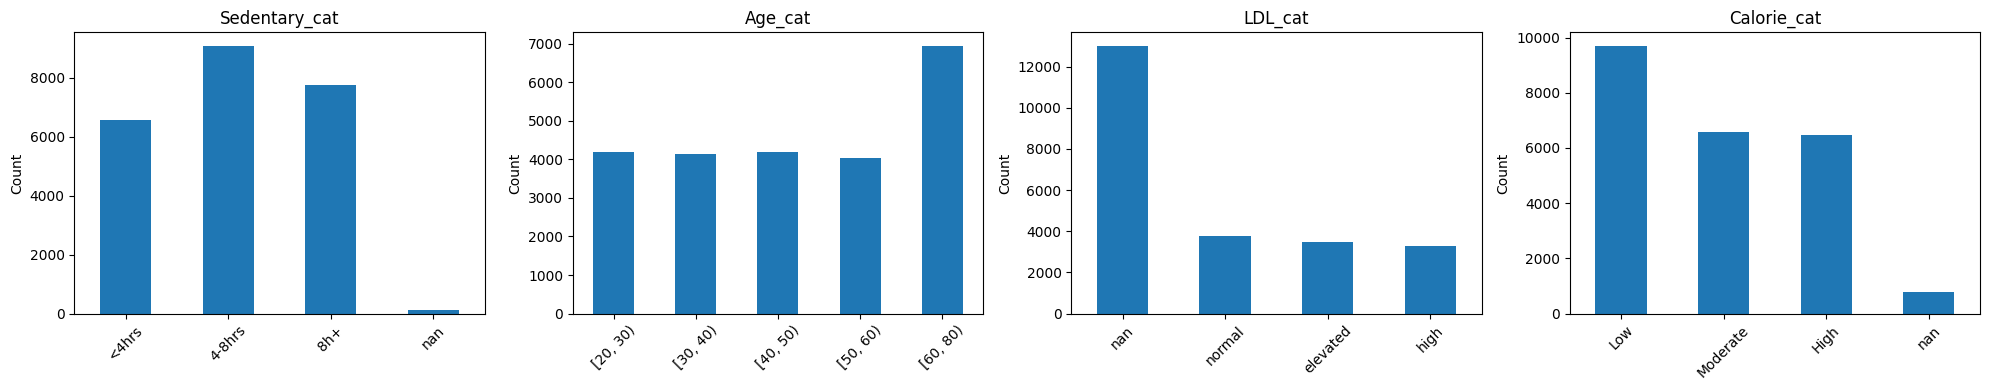

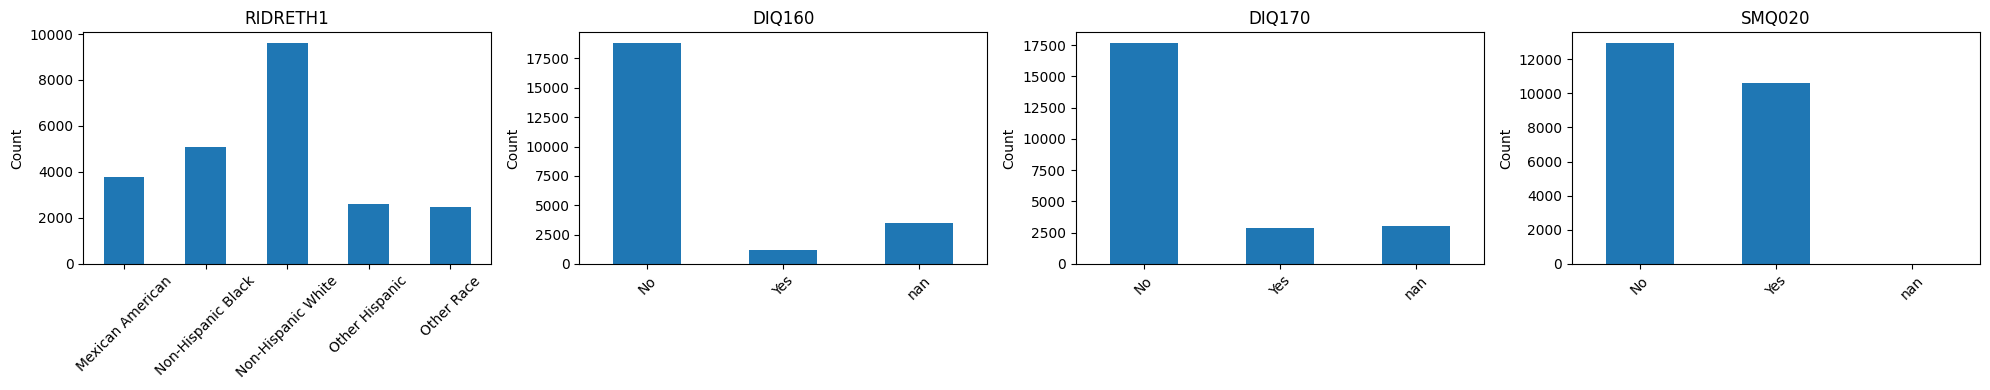

In [38]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


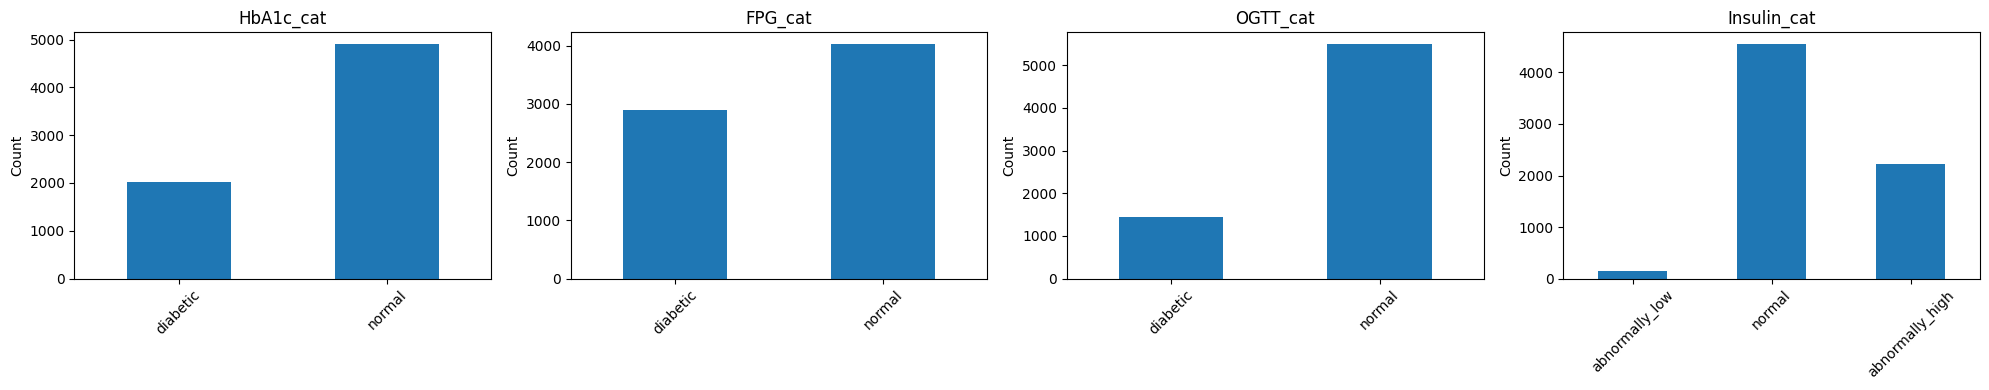

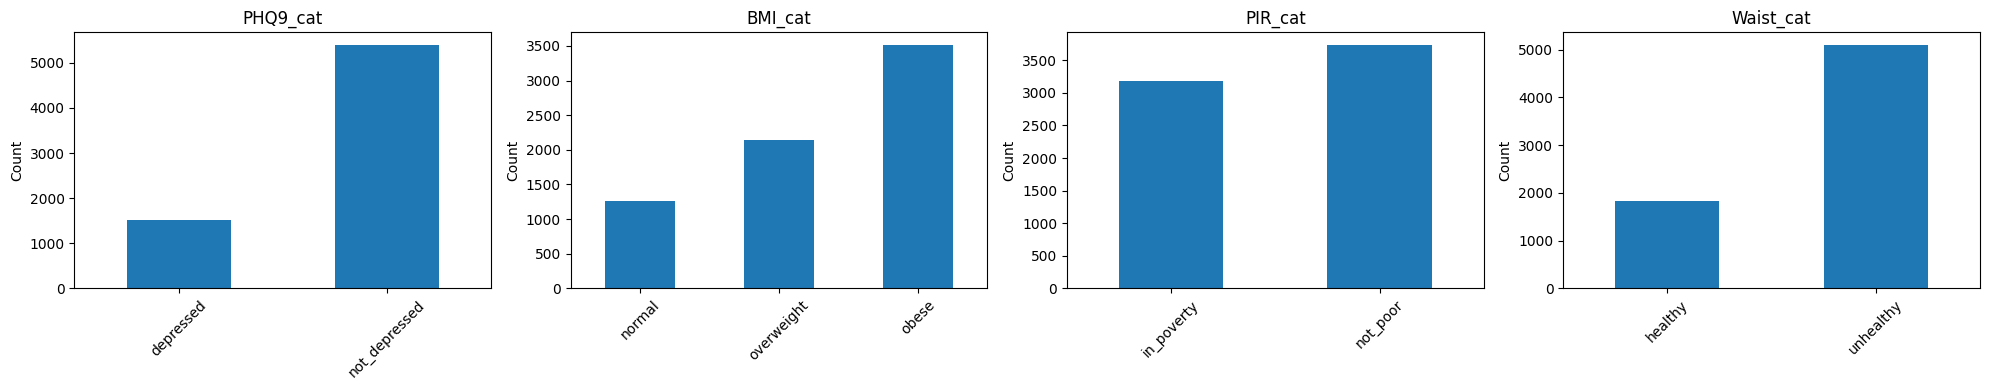

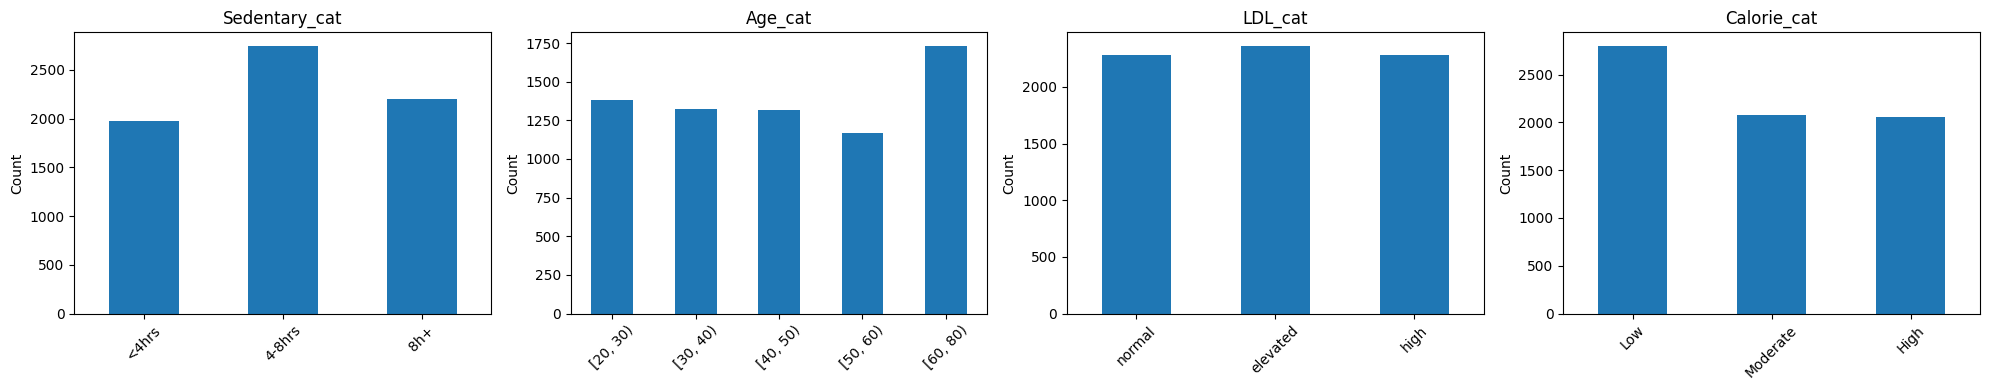

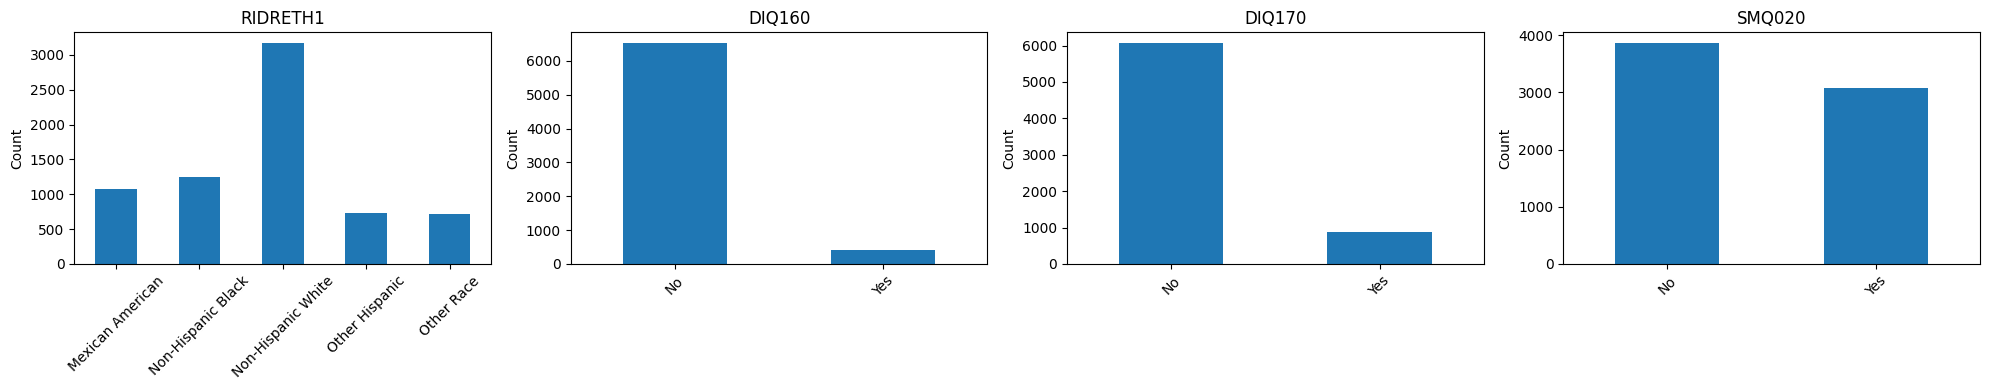

In [39]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)


Final ```df_model``` for logistic regression use

In [40]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = df[col].astype('category')

df_model = df.reset_index(drop=True)

/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df[col].astype('category')
/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df[col].astype('category')
/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [41]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23529 entries, 0 to 23528
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SEQN           23529 non-null  int64   
 1   RIDAGEYR       23529 non-null  Int64   
 2   RIAGENDR       23529 non-null  object  
 3   RIDRETH1       23529 non-null  object  
 4   INDFMPIR       21599 non-null  float64 
 5   DIQ160         20010 non-null  object  
 6   DIQ170         20509 non-null  object  
 7   SMQ020         23515 non-null  object  
 8   BMXWAIST       22875 non-null  float64 
 9   BMXBMI         23332 non-null  float64 
 10  DR1TKCAL       22763 non-null  float64 
 11  PAD680         23422 non-null  float64 
 12  LBDLDL         10513 non-null  float64 
 13  LBDGLUSI       10915 non-null  float64 
 14  LBXGH          22651 non-null  float64 
 15  LBDGLTSI       8371 non-null   float64 
 16  LBDINSI        10678 non-null  float64 
 17  PHQ9_total     23529 non-null  

In [42]:
df_model

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,...,OGTT_cat,Insulin_cat,PHQ9_cat,BMI_cat,PIR_cat,Waist_cat,Sedentary_cat,Age_cat,LDL_cat,Calorie_cat
0,41475,62,Female,Other Race,1.83,No,Yes,No,156.3,58.04,...,diabetic,NaN,depressed,obese,in_poverty,unhealthy,8h+,"[60, 80)",NaN,Low
1,41477,71,Male,Non-Hispanic White,1.50,NaN,NaN,Yes,109.5,30.05,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,4-8hrs,"[60, 80)",NaN,Low
2,41479,52,Male,Mexican American,2.20,No,No,No,95.4,27.56,...,normal,normal,not_depressed,obese,not_poor,unhealthy,<4hrs,"[50, 60)",elevated,High
3,41481,21,Male,Non-Hispanic Black,1.63,No,No,No,79.5,23.34,...,diabetic,NaN,not_depressed,overweight,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,High
4,41483,66,Male,Non-Hispanic Black,1.14,NaN,NaN,No,145.6,44.06,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,<4hrs,"[60, 80)",NaN,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23524,93690,32,Male,Other Hispanic,5.00,No,Yes,No,101.0,32.90,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[30, 40)",NaN,High
23525,93691,25,Male,Other Race,1.59,No,No,No,75.4,21.00,...,diabetic,NaN,not_depressed,normal,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,Moderate
23526,93695,76,Female,Non-Hispanic White,1.43,No,No,Yes,95.0,21.50,...,normal,abnormally_high,not_depressed,normal,in_poverty,unhealthy,4-8hrs,"[60, 80)",normal,Low
23527,93696,26,Male,Non-Hispanic White,2.99,No,Yes,No,110.2,33.80,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[20, 30)",NaN,Moderate


In [43]:
df_model.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'DIQ160',
       'DIQ170', 'SMQ020', 'BMXWAIST', 'BMXBMI', 'DR1TKCAL', 'PAD680',
       'LBDLDL', 'LBDGLUSI', 'LBXGH', 'LBDGLTSI', 'LBDINSI', 'PHQ9_total',
       'HbA1c_cat', 'FPG_cat', 'OGTT_cat', 'Insulin_cat', 'PHQ9_cat',
       'BMI_cat', 'PIR_cat', 'Waist_cat', 'Sedentary_cat', 'Age_cat',
       'LDL_cat', 'Calorie_cat'],
      dtype='object')

# **2. Data exploration**

# **3. Logistic Regression (Associative modelling)**

# **4. XGBoost analysis (Predictive modelling)**